# RAG Pipeline — Local Test Notebook

Test toàn bộ pipeline trên 200 bài báo CNN đã có sẵn trong `data/processed/` và collection `newsqa_cnn`.

**Không cần rebuild lại collection** — chỉ cần connect vào ChromaDB có sẵn ở `data/chroma_db/`.

**Các phần:**
1. Setup & connect
2. Kiểm tra collection stats
3. Load chunks → build BM25 index
4. Dense retrieval
5. BM25 retrieval
6. Hybrid retrieval (RRF)
7. So sánh 3 retriever trên 1 câu hỏi
8. Chunking stats (diagnostic)
9. *(Optional)* RAG generation nếu có `OPENAI_API_KEY`

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore", message="IProgress not found")

sys.path.insert(0, os.path.abspath(".."))

import yaml
with open("../configs/config.yaml") as f:
    config = yaml.safe_load(f)

print('Config loaded.')
print('Embedding:', config['embedding']['provider'], '/', config['embedding']['model_name'])
print('Chunking :', config['chunking']['strategy'], f"size={config['chunking']['chunk_size']} overlap={config['chunking']['chunk_overlap']}")

Config loaded.
Embedding: sentence-transformers / all-MiniLM-L6-v2
Chunking : recursive size=512 overlap=64


## 1. Connect tới ChromaDB

> ⚠️ **Lưu ý:** Collection hiện tại tên là `newsqa_cnn` (không phải `basic_collection`).
> Nếu bạn rebuild lại bằng `build_chroma_collection.py`, collection mới sẽ có tên bạn đặt.

In [2]:
from src.indexing.embeddings import get_embedding_function, SentenceTransformerEmbeddingFunction
from src.indexing.chroma_store import ChromaStore

ef = SentenceTransformerEmbeddingFunction(model_name='all-MiniLM-L6-v2')

print('Loading embedding model (downloads ~90 MB on first run)...')
ef._get_model()  # pre-load now so progress shows here, not silently during first query
print('Model ready.')

DB_PATH = '../data/chroma_db'
COLLECTION = 'newsqa_cnn'

store = ChromaStore(DB_PATH, ef)
print(ef.get_info())

Loading embedding model (downloads ~90 MB on first run)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10338.71it/s]


Model ready.
{'provider': 'sentence-transformers', 'model_name': 'all-MiniLM-L6-v2', 'output_dimensions': 384, 'max_input_tokens': 256, 'use_cases': 'Lightweight general-purpose: semantic search, clustering. Fast inference, low memory.'}


## 2. Collection Stats

In [3]:
import json

stats = store.get_collection_stats(COLLECTION)
print(f"Collection exists : {stats['exists']}")
print(f"Chunk count       : {stats['count']}")
print(f"DB metadata       : {stats['metadata']}")
print()
print('Embedding info:', json.dumps(stats['embedding_info'], indent=2))

Collection exists : True
Chunk count       : 408
DB metadata       : {'hnsw:space': 'cosine'}

Embedding info: {
  "provider": "sentence-transformers",
  "model_name": "all-MiniLM-L6-v2",
  "output_dimensions": 384,
  "max_input_tokens": 256,
  "use_cases": "Lightweight general-purpose: semantic search, clustering. Fast inference, low memory."
}


In [4]:
# Xem vài sample
sample = stats['sample']
for i, (sid, doc, meta) in enumerate(zip(sample['ids'], sample['documents'], sample['metadatas'])):
    print(f'[{i}] ID     : {sid}')
    print(f'    Article: {meta.get("article_id")} | chunk_index={meta.get("chunk_index")}')
    print(f'    Title  : {meta.get("title", "")[:60]}')
    print(f'    Text   : {doc[:150]}...')
    print()

[0] ID     : 923426cab4bf_chunk_0
    Article: 923426cab4bf | chunk_index=0
    Title  : Rescued men, children reunited with families in Pakistan
    Text   : (CNN) -- The 54 men and 14 boys rescued after being found chained this week at an Islamic religious school in Pakistan have been reunited with their f...

[1] ID     : 872a68fa18d9_chunk_0
    Article: 872a68fa18d9 | chunk_index=0
    Title  : Death sentence in Connecticut home invasion
    Text   : New Haven, Connecticut (CNN) -- A judge in New Haven sentenced a 31-year-old man to death Friday for his role in a deadly home invasion that killed a ...

[2] ID     : 872a68fa18d9_chunk_1
    Article: 872a68fa18d9 | chunk_index=1
    Title  : Death sentence in Connecticut home invasion
    Text   : Before assaulting and killing Jennifer Hawke-Petit, Hayes forced her to go to a bank and withdraw $15,000 from an account after finding evidence that ...

[3] ID     : d0f2fbafe880_chunk_0
    Article: d0f2fbafe880 | chunk_index=0
    Titl

## 3. Load tất cả chunks → Build BM25 Index

BM25 cần toàn bộ chunks trong memory. Chúng ta load từ ChromaDB (không cần đọc lại file JSONL).

In [5]:
from src.indexing.bm25_index import BM25Index

# Load toàn bộ chunks từ collection
raw = store.get(COLLECTION)  # trả về tất cả (không có filter)
chunks = [
    {'id': cid, 'text': doc, 'metadata': meta}
    for cid, doc, meta in zip(raw['ids'], raw['documents'], raw['metadatas'])
]
print(f'Loaded {len(chunks)} chunks từ ChromaDB')

# Build BM25
bm25 = BM25Index()
bm25.build(chunks)
print(f'BM25 index built: {bm25.size} documents')

# (Optional) Lưu lại để dùng sau không cần build lại
os.makedirs('../data/bm25', exist_ok=True)
bm25.save('../data/bm25/newsqa_cnn.pkl')
print('BM25 saved to data/bm25/newsqa_cnn.pkl')

Loaded 408 chunks từ ChromaDB
BM25 index built: 408 documents
BM25 saved to data/bm25/newsqa_cnn.pkl


## 4–6. Setup các Retrievers

In [6]:
from src.retrieval.dense import DenseRetriever
from src.retrieval.hybrid import BM25Retriever, HybridRetriever
from src.retrieval.reranker import NoOpReranker

TOP_K = 5

dense_retriever  = DenseRetriever(store, COLLECTION)
bm25_retriever   = BM25Retriever(bm25, {c['id']: c for c in chunks})
hybrid_retriever = HybridRetriever(
    dense=dense_retriever,
    bm25=bm25_retriever,
    dense_weight=0.7,
    sparse_weight=0.3,
)
reranker = NoOpReranker()

print('Retrievers ready.')

Retrievers ready.


## 7. So sánh 3 Retriever trên 1 câu hỏi

In [7]:
QUERY = "Who was sentenced to death for the home invasion?"

def show_results(label, results):
    print(f'=== {label} ===')
    for i, r in enumerate(results):
        print(f'  [{i+1}] id={r["id"]}  score={r["score"]:.4f}')
        print(f'       {r["text"][:120]}...')
    print()

show_results('Dense',  dense_retriever.retrieve(QUERY, TOP_K))
show_results('BM25',   bm25_retriever.retrieve(QUERY, TOP_K))
show_results('Hybrid', hybrid_retriever.retrieve(QUERY, TOP_K))

=== Dense ===
  [1] id=872a68fa18d9_chunk_0  score=0.4917
       New Haven, Connecticut (CNN) -- A judge in New Haven sentenced a 31-year-old man to death Friday for his role in a deadl...
  [2] id=872a68fa18d9_chunk_1  score=0.4732
       Before assaulting and killing Jennifer Hawke-Petit, Hayes forced her to go to a bank and withdraw $15,000 from an accoun...
  [3] id=d1065d58c066_chunk_0  score=0.4125
       (CNN) -- A Florida jury has recommended the death penalty for a plumber who kidnapped, raped and murdered a police detec...
  [4] id=084808ec0095_chunk_0  score=0.3733
       Toulouse (CNN) -- French police had no grounds on which to arrest gunman Mohammed Merah before he carried out three atta...
  [5] id=fe2767afb916_chunk_1  score=0.3724
       On the video, an unseen rebel is heard to say, "For the deputies, we have a special vehicle."

Twelve congressmen took t...

=== BM25 ===
  [1] id=9193ba0c1ca6_chunk_0  score=20.0210
       (CNN) -- Olympic figure skater Nancy Kerrigan

In [8]:
# Dense với timing breakdown
from src.retrieval.dense import dense_search

results, timing = dense_search(store, COLLECTION, QUERY, top_k=TOP_K)
print('Timing:', timing)
print(f'Top result: {results[0]["id"]} | score={results[0]["score"]:.4f}')

Timing: {'model_cold_start': False, 'embed_ms': 12.8, 'db_query_ms': 4.2}
Top result: 872a68fa18d9_chunk_0 | score=0.4917


## 8. Chunking Stats (diagnostic)

Xem phân phối chunk size để chọn `chunk_size` phù hợp.

In [10]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 833.9 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.3 MB 941.0 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.3 MB 941.0 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/9.3 MB 941.0 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.3 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.3 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.3 MB 996.1 kB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.3 MB 996.1 kB/s eta 0:00:08
   ------- ------------------------

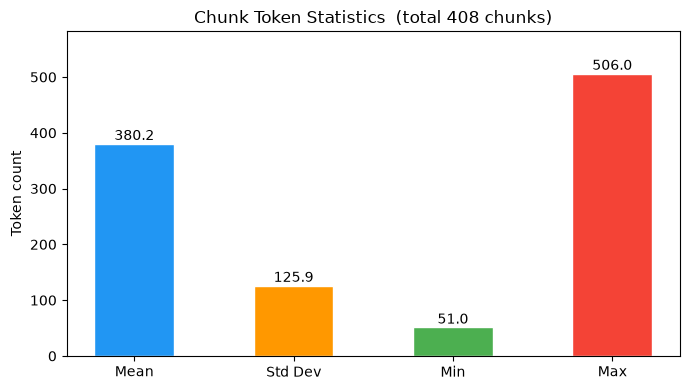

Chunks per article : -
Total chunks       : 408


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from src.evaluation.metrics import evaluate_chunking

chunk_stats = evaluate_chunking(chunks)

# Bar chart of summary stats
stat_keys = ['mean_tokens', 'std_tokens', 'min_tokens', 'max_tokens']
stat_vals = [chunk_stats.get(k, 0) for k in stat_keys]
labels    = ['Mean', 'Std Dev', 'Min', 'Max']
colors    = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, stat_vals, color=colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, stat_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.1f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Token count")
ax.set_title(f'Chunk Token Statistics  (total {chunk_stats.get("total_chunks", len(chunks))} chunks)')
ax.set_ylim(0, max(stat_vals) * 1.15)
plt.tight_layout()
plt.show()

print(f"Chunks per article : {chunk_stats.get('chunks_per_article', '-')}")
print(f"Total chunks       : {chunk_stats.get('total_chunks', len(chunks))}")

C:\Users\duyla\AppData\Local\Temp\ipykernel_9412\2200702815.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax2.boxplot(token_counts, vert=True, patch_artist=True,


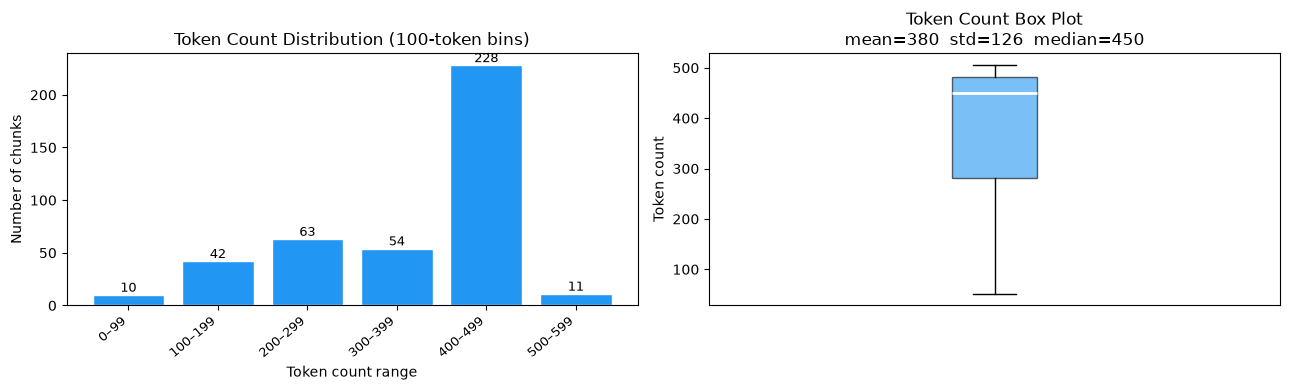

In [12]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")
token_counts = [len(enc.encode(c["text"])) for c in chunks]

# Bucket into 100-token bins
buckets = {}
for t in token_counts:
    b = (t // 100) * 100
    buckets[b] = buckets.get(b, 0) + 1

b_labels = [f"{b}–{b+99}" for b in sorted(buckets)]
b_counts = [buckets[b] for b in sorted(buckets)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart per 100-token bucket
ax1.bar(range(len(b_labels)), b_counts, color="#2196F3", edgecolor="white")
ax1.set_xticks(range(len(b_labels)))
ax1.set_xticklabels(b_labels, rotation=40, ha="right", fontsize=9)
ax1.set_xlabel("Token count range")
ax1.set_ylabel("Number of chunks")
ax1.set_title("Token Count Distribution (100-token bins)")
for i, v in enumerate(b_counts):
    ax1.text(i, v + 0.2, str(v), ha="center", va="bottom", fontsize=9)

# Right: box plot
bp = ax2.boxplot(token_counts, vert=True, patch_artist=True,
                 boxprops=dict(facecolor="#2196F3", alpha=0.6),
                 medianprops=dict(color="white", linewidth=2))
ax2.set_ylabel("Token count")
ax2.set_title(
    f"Token Count Box Plot\n"
    f"mean={np.mean(token_counts):.0f}  std={np.std(token_counts):.0f}  "
    f"median={int(np.median(token_counts))}"
)
ax2.set_xticks([])

plt.tight_layout()
plt.show()

## 9. Mini retrieval benchmark (không cần API key)

Tạo 5 câu hỏi thủ công và đánh giá retrieval metrics nhanh.

Q: Who was sentenced to death for the home invasion?
   relevant: ['872a68fa18d9_chunk_0']
   top3    : ['872a68fa18d9_chunk_0', 'd1065d58c066_chunk_0', '872a68fa18d9_chunk_1']

Q: How many students were found chained in Pakistan?
   relevant: ['923426cab4bf_chunk_0']
   top3    : ['923426cab4bf_chunk_0', '8a323a3209d0_chunk_2', '64d1bb9eed7b_chunk_0']



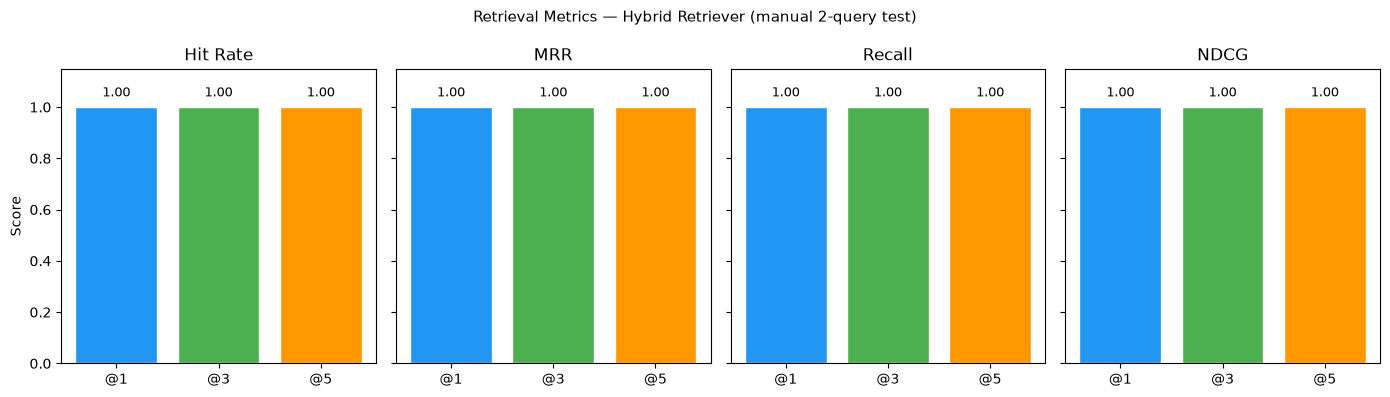

In [13]:
from src.evaluation.metrics import evaluate_retrieval

manual_test = [
    {
        'question': 'Who was sentenced to death for the home invasion?',
        'relevant_chunk_ids': ['872a68fa18d9_chunk_0'],
    },
    {
        'question': 'How many students were found chained in Pakistan?',
        'relevant_chunk_ids': ['923426cab4bf_chunk_0'],
    },
]

retrieval_samples = []
for entry in manual_test:
    q = entry['question']
    retrieved = hybrid_retriever.retrieve(q, top_k=10)
    retrieved_ids = [r["id"] for r in retrieved]
    retrieval_samples.append({
        'relevant_chunk_ids': entry['relevant_chunk_ids'],
        'retrieved_ids': retrieved_ids,
    })
    print(f"Q: {q}")
    print(f"   relevant: {entry['relevant_chunk_ids']}")
    print(f"   top3    : {retrieved_ids[:3]}")
    print()

K_VALUES = [1, 3, 5]
metrics = evaluate_retrieval(retrieval_samples, k_values=K_VALUES)

# ── Chart ──────────────────────────────────────────────────────────────────
metric_types = ['hit_rate', 'mrr', 'recall', 'ndcg']
nice_names   = ['Hit Rate', 'MRR', 'Recall', 'NDCG']
palette      = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, len(metric_types), figsize=(14, 4), sharey=True)
for ax, mtype, nice in zip(axes, metric_types, nice_names):
    vals = [metrics.get(f"{mtype}@{k}", 0) for k in K_VALUES]
    bars = ax.bar([f"@{k}" for k in K_VALUES], vals, color=palette, edgecolor="white")
    ax.set_ylim(0, 1.15)
    ax.set_title(nice)
    if ax == axes[0]:
        ax.set_ylabel("Score")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.03,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Retrieval Metrics — Hybrid Retriever (manual 2-query test)", fontsize=11)
plt.tight_layout()
plt.show()

## 10. *(Optional)* RAG Generation

Cần `OPENAI_API_KEY` trong environment. Nếu không có thì skip cell này.

In [14]:
import os
# os.environ['OPENAI_API_KEY'] = 'sk-...'  # uncomment nếu chưa set

if not os.environ.get('OPENAI_API_KEY'):
    print('OPENAI_API_KEY not set — skip generation cells.')
else:
    from src.llm import get_llm
    from src.agents.rag_agent import RAGAgent
    from src.retrieval.reranker import NoOpReranker

    llm = get_llm(config)
    agent = RAGAgent(
        retriever=hybrid_retriever,
        reranker=NoOpReranker(),
        llm=llm,
        top_k=10,
        rerank_top_n=5,
    )

    result = agent.run("Who was sentenced to death for the Connecticut home invasion?")
    print('Question:', result['question'])
    print('Answer  :', result['answer'])
    print('Timing  :', result['timing_ms'])
    print()
    print('Top reranked chunk:')
    print(result['reranked_chunks'][0]['text'][:300])

OPENAI_API_KEY not set — skip generation cells.


## 11. *(Optional)* Thử chunk lại với config khác

Nếu muốn thử `chunk_size` khác mà không rebuild ChromaDB.

In [15]:
from src.ingestion.chunker import get_chunker
import glob, json

test_config = {
    'chunking': {'strategy': 'recursive', 'chunk_size': 256, 'chunk_overlap': 32}
}
chunker = get_chunker(test_config)

# Chunk 1 file để xem output
sample_file = glob.glob('../data/processed/*_clean.json')[0]
with open(sample_file) as f:
    article_data = json.load(f)

result_chunks = chunker.chunk_article(article_data, filename=os.path.basename(sample_file))

print(f'Article: {article_data["metadata"]["title"]}')
print(f'Text length: {len(article_data["text"])} chars')
print(f'Produced {len(result_chunks)} chunks with chunk_size=256')
print()
for c in result_chunks:
    import tiktoken
    n = len(tiktoken.get_encoding('cl100k_base').encode(c['text']))
    print(f'  chunk_{c["metadata"]["chunk_index"]}: {n} tokens | {c["text"][:80]}...')

Article: Rescued men, children reunited with families in Pakistan
Text length: 1668 chars
Produced 2 chunks with chunk_size=256

  chunk_0: 230 tokens | (CNN) -- The 54 men and 14 boys rescued after being found chained this week at a...
  chunk_1: 144 tokens | "The operation was successful, and we plan on continuing our work to ensure that...
